In [13]:
import pandas as pd

# Đọc dữ liệu từ tệp
df_FPT_4_2_3 = pd.read_csv("./DATA EXPLORER CONTEST/Data - 12ndMar/4.2.3.FPT.csv")
df_cafef = pd.read_excel("daily_dominant_sentiment_no_title.xlsx")

# Đổi kiểu dữ liệu của cột 'Date' trong df_FPT_4_2_3
df_FPT_4_2_3['Date'] = pd.to_datetime(df_FPT_4_2_3['Date'], format='%d/%m/%Y')


# Hợp nhất dữ liệu theo 'Date', mặc định điền neutral nếu không có tin
merged_df = pd.merge(df_FPT_4_2_3, df_cafef, on='Date', how='left')

# Điền mặc định cho các giá trị bị thiếu
merged_df['sentiment'] = merged_df['sentiment'].fillna('neutral')
merged_df['sentiment_score'] = merged_df['sentiment_score'].fillna(0)

# Kiểm tra dữ liệu sau khi hợp nhất
print(merged_df[['Date', 'sentiment', 'sentiment_score']].head())




        Date sentiment  sentiment_score
0 2025-03-12  negative              0.0
1 2025-03-11   neutral              1.0
2 2025-03-10   neutral              1.0
3 2025-03-07  negative              0.0
4 2025-03-06  positive              2.0


In [9]:
# Lưu DataFrame đã hợp nhất vào tệp CSV
merged_df.to_csv("data.csv", index=False)

In [14]:
# Lấy cột Date làm index cho DataFrame
merged_df.set_index('Date', inplace=True)

# Sắp xếp dữ liệu theo ngày tháng tăng dần
merged_df.sort_index(inplace=True)

# Kiểm tra dữ liệu sau khi chuyển đổi
print(merged_df.info())
print(merged_df.head())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 240 entries, 2024-03-26 to 2025-03-12
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   StockID          240 non-null    object 
 1   Total Volume     240 non-null    int64  
 2   Total Value      240 non-null    int64  
 3   Market Cap       240 non-null    int64  
 4   Closing Price    240 non-null    int64  
 5   Price Change     240 non-null    int64  
 6   Price Change %   240 non-null    float64
 7   Matched Volume   240 non-null    int64  
 8   Matched Value    240 non-null    int64  
 9   sentiment        240 non-null    object 
 10  sentiment_score  240 non-null    float64
dtypes: float64(2), int64(7), object(2)
memory usage: 22.5+ KB
None
           StockID  Total Volume  Total Value  Market Cap  Closing Price  \
Date                                                                       
2024-03-26     FPT       3110290       365684   146046421 

# Long Short Term Memory (LSTM)

In [44]:
# import các thư viện cần thiết
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")



In [36]:
# --- Lấy các cột cần thiết ---
features = ['Total Volume', 'Total Value', 'Market Cap', 
            'Price Change', 'Price Change %', 
            'Matched Volume', 'Matched Value', 'sentiment_score']
target = 'Closing Price'

# --- Chuẩn hóa dữ liệu ---
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_all = scaler_x.fit_transform(merged_df[features])
y_all = scaler_y.fit_transform(merged_df[[target]])

# --- Tạo sequence toàn bộ dữ liệu ---
time_steps = 70

def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(time_steps, len(X)):
        Xs.append(X[i-time_steps:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_all, y_all, time_steps)

# --- Chia train/test từ toàn bộ sequence ---
split_index = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split_index], X_seq[split_index:]
y_train, y_test = y_seq[:split_index], y_seq[split_index:]


In [47]:
# Xây dựng mô hình LSTM
model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Huấn luyện
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.1, verbose=1)

# Dự đoán
y_pred = model.predict(X_test)
y_pred_inverse = scaler_y.inverse_transform(y_pred)
y_test_inverse = scaler_y.inverse_transform(y_test)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.2313 - val_loss: 0.2140
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0322 - val_loss: 0.0234
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0277 - val_loss: 0.1000
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0164 - val_loss: 0.1132
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0159 - val_loss: 0.0736
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0153 - val_loss: 0.0563
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0146 - val_loss: 0.0648
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0142 - val_loss: 0.0656
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0115 - val_loss: 0.0346
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0096 - val_loss: 0.0301
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0083 - val_loss: 0.0076
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0054 - val_l

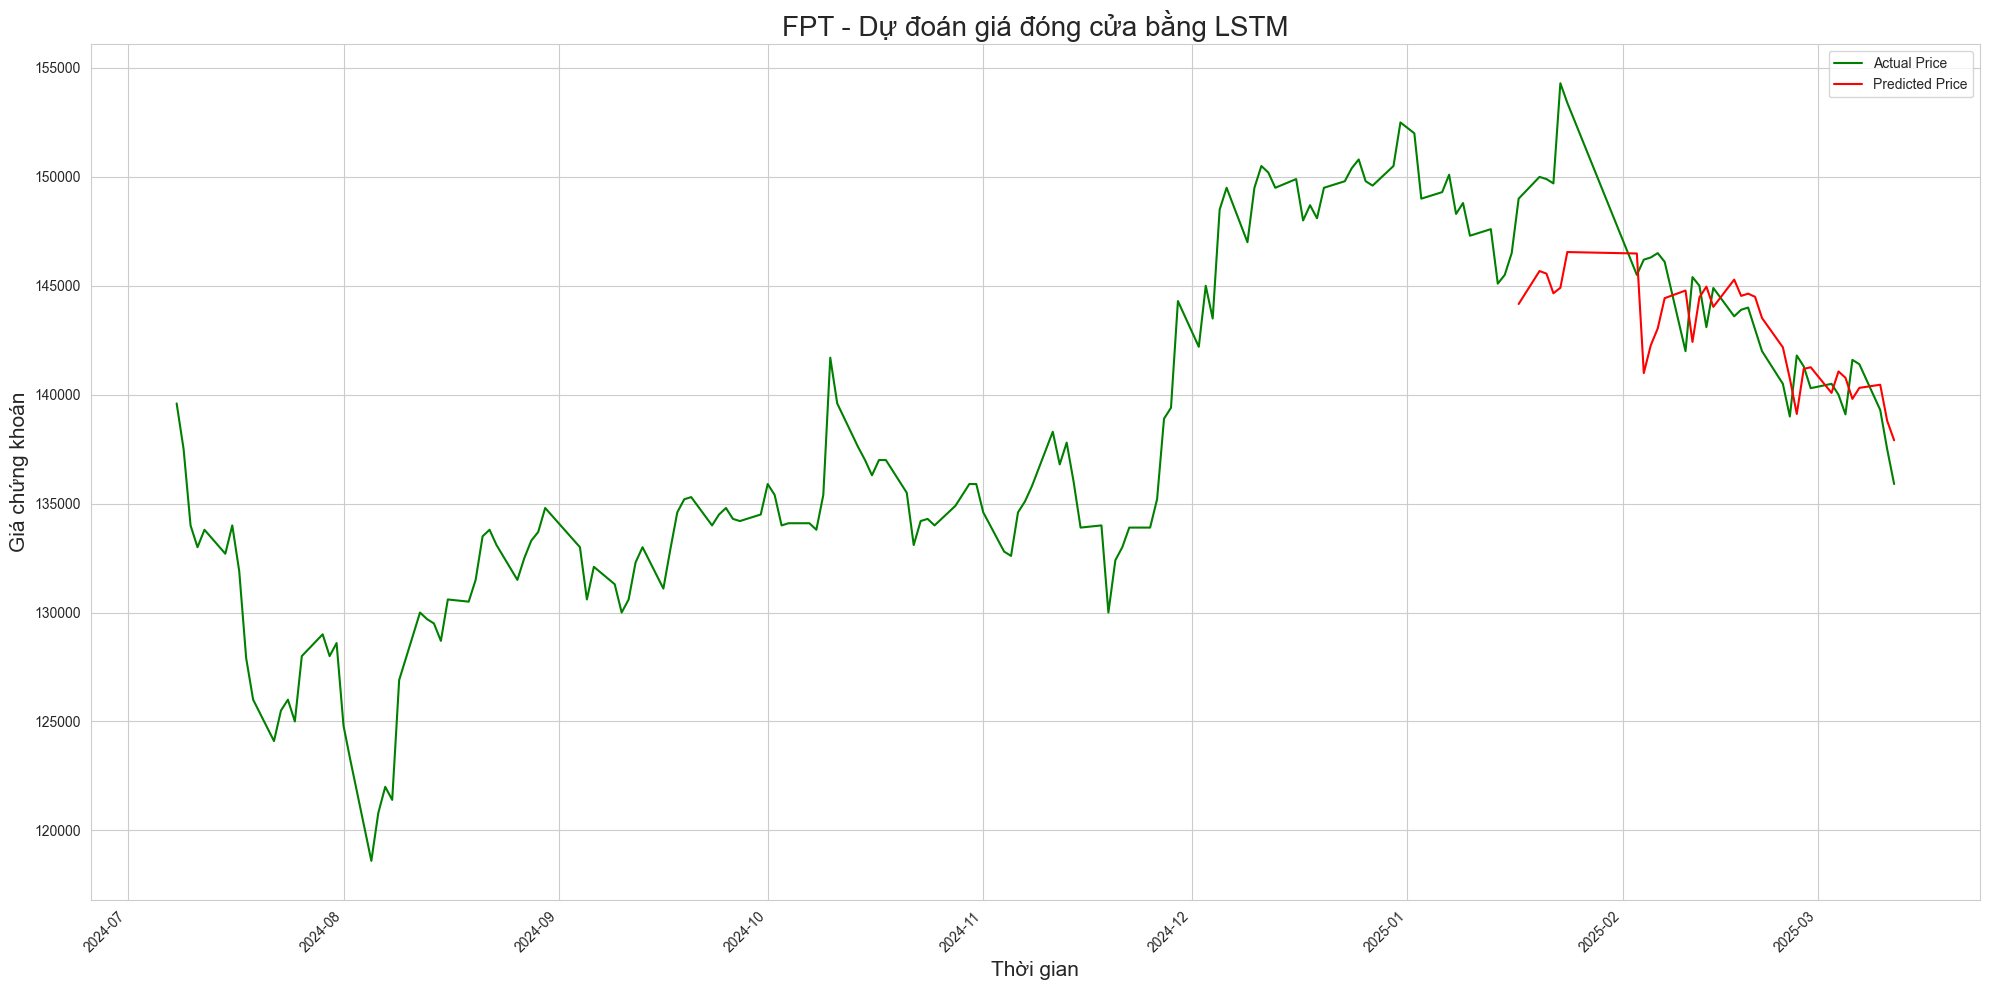

In [48]:
# Kết hợp toàn bộ y thực tế (train + test)
full_dates = np.concatenate([train_dates, test_dates])
full_y_actual = np.concatenate([y_train_inverse, y_test_inverse])

# --- Vẽ biểu đồ ---
plt.figure(figsize=(20,10))
sns.set_style("whitegrid")

# Vẽ toàn bộ y thực tế
plt.plot(full_dates, full_y_actual.flatten(), label='Actual Price', color='green')

# Vẽ giá dự đoán
plt.plot(test_dates, y_pred_inverse.flatten(), label='Predicted Price', color='red')

plt.title("FPT - Dự đoán giá đóng cửa bằng LSTM", fontsize=20)
plt.xlabel("Thời gian", fontsize=15)
plt.ylabel("Giá chứng khoán", fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


In [51]:
# --- In ra các giá trị thực tế sau khi inverse transform ---
print("Giá trị thực tế (y_test_inverse):")
print(y_pred_inverse.flatten())

Giá trị thực tế (y_test_inverse):
[144164.34 145677.45 145560.1  144657.89 144909.6  146549.64 146483.05
 140995.45 142266.94 143041.31 144432.14 144783.17 142424.08 144468.14
 144962.39 144033.39 145284.14 144536.89 144639.6  144494.08 143520.86
 142173.95 140745.88 139116.34 141182.03 141261.62 140084.36 141068.67
 140779.19 139808.2  140313.88 140458.89 138804.75 137907.39]


In [52]:
# --- Đánh giá mô hình ---
mse = mean_squared_error(y_test_inverse, y_pred_inverse)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_inverse, y_pred_inverse)
r2 = r2_score(y_test_inverse, y_pred_inverse)

# --- In kết quả ---
print(f"MSE  (Mean Squared Error): {mse:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"MAE  (Mean Absolute Error): {mae:.2f}")
print(f"R²   (R-squared): {r2:.4f}")

MSE  (Mean Squared Error): 9981993.13
RMSE (Root Mean Squared Error): 3159.43
MAE  (Mean Absolute Error): 2435.86
R²   (R-squared): 0.4498
